# **Лабораторна робота №8**

### **Тема.** Структура даних граф. Алгоритми на графах
### **Мета:** засвоїти представлення структури даних граф та основні алгоритми роботи з ними засобами Python.
**Виконав:** Заїченко А.С. 

In [33]:
!pip install networkx matplotlib

In [34]:
#Створення Vertex
class Vertex:
 def __init__(self, key):
    self.id = key 
    self.connectedTo = {} 
 def addNeighbor(self, nbr, weight=0):
    self.connectedTo[nbr] = weight
 def __str__(self):
    return str(self.id) + ' connectedTo: ' + str([x.id for x in
self.connectedTo])
    def getConnections(self):
        return self.connectedTo.keys()
 def getId(self):
    return self.id
 def getWeight(self, nbr):
    return self.connectedTo[nbr]

In [35]:
#Створення Graph
class Graph:
 def __init__(self):
    self.vertList = {}
    self.numVertices = 0
 def addVertex(self,key):
    self.numVertices = self.numVertices + 1
    newVertex = Vertex(key)
    self.vertList[key] = newVertex
    return newVertex
 def getVertex(self,n):
    if n in self.vertList:
        return self.vertList[n]
    else:
        return None
 def __contains__(self,n):
    return n in self.vertList
 def addEdge(self,f,t,cost=0):
    if f not in self.vertList:
        nv = self.addVertex(f)
    if t not in self.vertList:
        nv = self.addVertex(t)
    self.vertList[f].addNeighbor(self.vertList[t], cost)
 def getVertices(self):
    return self.vertList.keys()
 def __iter__(self):
     return iter(self.vertList.values())


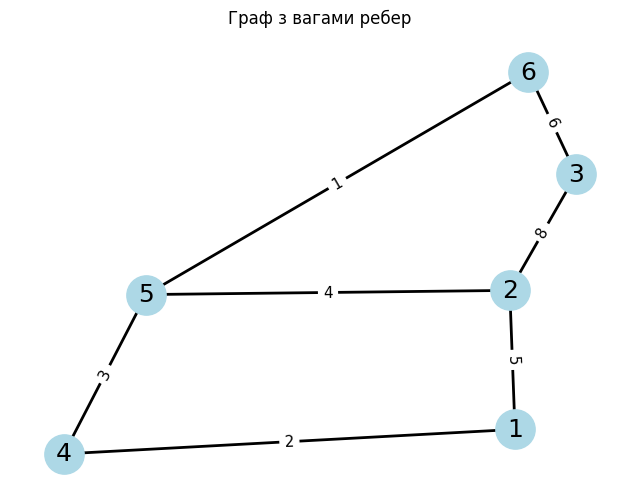

In [36]:
#Візуалізація графа
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from([1, 2, 3, 4, 5, 6])

G.add_weighted_edges_from([
    (1, 2, 5),
    (1, 4, 2),
    (2, 3, 8),
    (2, 5, 4),
    (3, 6, 6),
    (4, 5, 3),
    (5, 6, 1)
])
pos = nx.spring_layout(G, seed=15)
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue')

nx.draw_networkx_labels(G, pos, font_size=18, font_family='sans-serif')

nx.draw_networkx_edges(G, pos, width=2)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11)
plt.title("Граф з вагами ребер")
plt.axis('off')

plt.show()

In [37]:
#Пошук у глибину
def dfs(graph, start, visited=None):
    if visited is None:
        visited = set()

    visited.add(start)
    print(start, end=" ")
    for next_vertex in graph.neighbors(start):
        if next_vertex not in visited:
            dfs(graph, next_vertex, visited)

print("DFS:")
dfs(G, 1)
print()

DFS:
1 2 3 6 5 4 


In [38]:
#Усі шляхи
def dfs_paths(graph, start, goal, path=None):
    if path is None:
        path = [start]
    if start == goal:
        yield path
    for next_vertex in graph.neighbors(start):
        if next_vertex not in path:
            yield from dfs_paths(graph, next_vertex, goal, path + [next_vertex])
print("Усі шляхи DFS:")
print(list(dfs_paths(G, 1, 6)))

Усі шляхи DFS:
[[1, 2, 3, 6], [1, 2, 5, 6], [1, 4, 5, 2, 3, 6], [1, 4, 5, 6]]


In [39]:
#Пошук у ширину
def bfs_paths(graph, start, goal):

    queue = [(start, [start])]
    while queue:
        vertex, path = queue.pop(0)
        for next_vertex in graph.neighbors(vertex):
            if next_vertex == goal:
                yield path + [next_vertex]
            elif next_vertex not in path:
                queue.append((next_vertex, path + [next_vertex]))

print("Усі шляхи BFS:")
print(list(bfs_paths(G, 1, 6)))

Усі шляхи BFS:
[[1, 2, 3, 6], [1, 2, 5, 6], [1, 4, 5, 6], [1, 4, 5, 2, 3, 6]]


In [40]:
#Алгоритм Дейкстри
lengths, paths = nx.single_source_dijkstra(G, 1)
print("Дейкстра - найкоротші відстані:")
print(lengths)
print("Дейкстра - шляхи:")
print(paths)

Дейкстра - найкоротші відстані:
{1: 0, 4: 2, 2: 5, 5: 5, 6: 6, 3: 12}
Дейкстра - шляхи:
{1: [1], 4: [1, 4], 2: [1, 2], 5: [1, 4, 5], 6: [1, 4, 5, 6], 3: [1, 4, 5, 6, 3]}


In [41]:
#Алгоритм Беллмана-Форда
lengths = nx.single_source_bellman_ford_path_length(G, 1)
print("Беллман-Форд:")
print(lengths)

Беллман-Форд:
{1: 0, 2: 5, 4: 2, 3: 12, 5: 5, 6: 6}


**1. Що таке граф у термінах теорії графів? Наведіть приклади реальних ситуацій, де можна застосовувати графи.**

У теорії графів граф - це сукупність двох множин: множини вершин (або вузлів) та множини ребер

Приклади: соціальні мережі, комп'ютерні мережі, навігація


**2. Які основні види графів існують? Наведіть відмінності між орієнтованими і неорієнтованими графами.**

Графи бувають:
* неорієнтовані (ребро працює в обидва боки)
* орієнтовані (напрямок важливий)
* зважені / незважені
* зв’язні / незв’язні
* циклічні / ациклічні


**3. Як можна представити граф у пам’яті комп'ютера? Опишіть структури даних, які використовуються для зберігання графів.**

1) Матриця суміжності - 2D масив, швидкий доступ, займає багато пам’яті
2) Список суміжності - словник або список списків, економить пам’ять, найпопулярніший варіант
3) Список ребер - просто список пар (u, v)

**4. Як працює алгоритм пошуку в ширину (BFS) на графах? Наведіть приклади ситуацій, де застосовується цей алгоритм.**

Обхід рівнями за допомогою черги. Використовується для найкоротших шляхів у простих графах.

**5. Що таке алгоритм пошуку в глибину (DFS) на графах? Як він відрізняється від BFS? Дайте приклади задач, де використовується DFS.**

Іде якнайглибше, потім повертається назад. Використовує стек або рекурсію.


**6. Опишіть алгоритм Дейкстри для пошуку найкоротшого шляху в графі. Які умови повинні виконуватися для успішної роботи цього алгоритму?**

Алгоритм Дейкстри знаходить найкоротші шляхи від однієї заданої вершини до всіх інших у зваженому графі. Алгоритм Дейкстри успішно та коректно працює лише тоді, коли граф не містить ребер з від'ємною вагою.
